# Revised Köppen ram-pressure calculation for the 40-galaxy MAUVE sample

**Preferred model: AMIGA initial H I mass + Wang et al. (2016) initial H I size + Köppen et al. (2018) stripping physics**

This notebook computes, galaxy by galaxy,

$$
p_{\rm def},\qquad p_{\rm cfg},\qquad p_{\rm loc},
$$

and their ratios. It deliberately changes only the galaxy-side initial conditions while keeping the Köppen Virgo ICM, escape-speed, and restoring-force prescriptions fixed. It also propagates the main stated uncertainties with 20,000 Monte Carlo draws per galaxy.

The calculation is organized as an auditable chain: inputs → initial H I mass → initial H I size → stripping/configuration radii → pressures → environmental-stage diagnostics. All 40 galaxies remain in the table; unavailable or physically undefined quantities are represented by `NaN`, never by zero.

## 1. Three-model design and interpretation

| Model | Initial H I mass | Initial cutoff | Role here |
|---|---|---|---|
| A | Gavazzi/Köppen | $1.5R_{\rm opt}$ | Published Köppen appendix values used as the external reference |
| B | AMIGA/Jones | $1.5R_{\rm opt}$ | Isolates the change in expected H I mass |
| C | AMIGA/Jones | Wang16 $D_{\rm HI,0}/2$ | Preferred revised model |

For Model C,

$$
\log D_{\rm HI,0}=0.506\log M_{\rm HI,0}-3.293,
\qquad r_{\max}=D_{\rm HI,0}/2.
$$

The main criterion is retained as a *continuous* ratio. The conditional probability $P(p_{\rm def}>2p_{\rm loc}\mid {\rm DEF}>0)$ is reported alongside $P({\rm DEF}>0)$, because $p_{\rm def}$ is not defined by the truncation inversion when a draw is H I-excess rather than deficient.

## 2. Provenance and important limits

- HyperLeda `logd25`, morphology $T$, and rotation velocities are the frozen 2026-08-15 snapshot embedded below. HyperLeda diameters match the system used by the AMIGA calibration.
- Observed H I masses and MAUVE stages come from local `mauve_master_wiki_newclass.fits`.
- Coordinates come from local `simbad_object_crosswalk.csv`; fixed galaxy colours come from `MAUVE_galaxy_colors.dat`.
- AMIGA coefficients are the morphology-dependent Jones et al. calibration used in the preceding notebook. The all-type relation is retained as a sensitivity column.
- [Wang et al. (2016)](https://academic.oup.com/mnras/article/460/2/2143/2609089) define $D_{\rm HI}$ at $\Sigma_{\rm HI}=1\,M_\odot\,{\rm pc}^{-2}$ and find 0.06 dex scatter.
- [Köppen et al. (2018)](https://academic.oup.com/mnras/article/479/4/4367/5040236) provide the pressure prescription, Virgo cluster model, and VIVA isophotal radii. Their appendix values for the MAUVE overlap are stored in root-level `koppen2018_viva_mauve_overlap.csv`.

No resolved VIVA H I maps are present in this local workspace. Consequently, $p_{\rm cfg}$ is calculated from the **published VIVA isophotal radius** for 33/40 galaxies, not remeasured from map pixels. The other seven remain missing. A 0.10 dex radius uncertainty is adopted from Köppen's comparison of VIVA diameter measurements; this should be revisited once maps and a reproducible radius-measurement protocol are available.

- **LOS velocity update:** the local master `vel` column is treated as heliocentric and compared with [SIMBAD M87](https://simbad.cds.unistra.fr/simbad/sim-basic?Ident=M87), $1256\pm36$ km s$^{-1}$. The FITS header does not provide row-level velocity provenance or frame metadata, so this is documented as an assumption.

In [1]:
# Core scientific and display dependencies.
from io import StringIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from astropy.coordinates import SkyCoord
from astropy.table import Table
import astropy.units as u
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:.4g}")

# Reproducibility controls and fixed project choices.
RNG_SEED = 20260817
N_MC = 20_000
DISTANCE_MPC = 16.5
SIGMA_LOG_MHI_OBS_DEX = 0.10
VROT_FRACTIONAL_FALLBACK = 0.01
SIGMA_LOG_PLOC_DEX = np.log10(2.0)
M87_VLOS_KMS = 1256.0
M87_VLOS_ERR_KMS = 36.0

# Köppen et al. disk parameters.
RHI_MAX_OVER_ROPT_B = 1.5
WANG_SLOPE = 0.506
WANG_INTERCEPT = -3.293
WANG_SCATTER_DEX = 0.06
SIGMA_LOG_RHI_OBS_DEX = 0.10
RESTORING_G = 2.0
STELLAR_BOOST_A = 15.0
R0_AT_ROPT_15_KPC = 2.0  # kpc

# Köppen et al. Virgo ICM and dark-matter beta models.
ICM_N0_CM3 = 0.04
ICM_RC_KPC = 13.4
ICM_BETA = 0.47
DM_RHO0_MSUN_PC3 = 3.8e-4
DM_RC_KPC = 320.0
DM_BETA = 1.0
G_KPC_KMS2_MSUN = 4.30091e-6

# One solar mass of atomic hydrogen spread over one square parsec gives this
# H-atom column; dividing by one kpc converts column/radius to number density.
MSUN_PC2_TO_H_CM2 = 1.2480e20
KPC_TO_CM = 3.0856775814913673e21
SURFACE_OVER_KPC_TO_CM3 = MSUN_PC2_TO_H_CM2 / KPC_TO_CM

HERE = Path.cwd()
MASTER_PATH = HERE / "mauve_master_wiki_newclass.fits"
COLOR_PATH = HERE / "MAUVE_galaxy_colors.dat"
COORD_PATH = HERE / "simbad_object_crosswalk.csv"
KOPPEN_VIVA_PATH = HERE / "koppen2018_viva_mauve_overlap.csv"

print(f"Working directory: {HERE}")
print(f"Monte Carlo draws per galaxy: {N_MC:,}")

Working directory: /Users/Igniz/Desktop/ICRAR/further
Monte Carlo draws per galaxy: 20,000


## 3. Assemble the 40-galaxy MAUVE table

The master catalogue supplies one row per physical galaxy. The coordinate crosswalk is merged one-to-one and checked against the full sample. `NGC4567` and `NGC4568` remain separate components; a combined `NGC4567_8` row would be an error here.

In [2]:
def clean_text(value):
    """Decode byte strings from FITS tables and remove surrounding whitespace."""
    if isinstance(value, (bytes, np.bytes_)):
        value = value.decode("utf-8")
    return str(value).strip()


def read_mauve_colors(path):
    """Read the approved project colour mapping, ignoring its comment header."""
    colors = {}
    with open(path, "r", encoding="utf-8") as handle:
        for line in handle:
            if not line.strip() or line.lstrip().startswith("#"):
                continue
            fields = line.split()
            colors[fields[1]] = fields[3]
    return colors


master = Table.read(MASTER_PATH).to_pandas()
master["Galaxy"] = master["Galaxy"].map(clean_text)
master["stage"] = master["class"].astype(int)
master["stage_label"] = master["stage"].map({1: "pre-peak", 2: "close-to-peak", 3: "post-peak"})

coords = pd.read_csv(COORD_PATH).rename(columns={"component": "Galaxy"})
coords["Galaxy"] = coords["Galaxy"].map(clean_text)

galaxy_colors = read_mauve_colors(COLOR_PATH)

assert len(master) == 40, f"Expected 40 physical MAUVE galaxies, found {len(master)}"
assert master["Galaxy"].is_unique, "The MAUVE master catalogue contains duplicate galaxy IDs"
assert "NGC4567_8" not in set(master["Galaxy"]), "Combined pair ID found in a component-level analysis"
assert set(master["Galaxy"]) == set(coords["Galaxy"]), "SIMBAD cross-match does not match the MAUVE sample"
assert set(master["Galaxy"]).issubset(galaxy_colors), "Fixed colours are missing for one or more galaxies"

sample = master.merge(
    coords[["Galaxy", "main_id", "ra_deg", "dec_deg", "coordinate_bibcode"]],
    on="Galaxy",
    how="left",
    validate="one_to_one",
)
sample["galaxy_color"] = sample["Galaxy"].map(galaxy_colors)

display(sample[["Galaxy", "logMHI", "vel", "stage_label", "main_id", "ra_deg", "dec_deg"]])
print("Strict sample assembly passed: 40 unique component galaxies.")

,Galaxy,logMHI,vel,stage_label,main_id,ra_deg,dec_deg
0,NGC4189,8.78,1995,pre-peak,NGC 4189,183.4,13.42
1,NGC4192,9.655,-118,pre-peak,M 98,183.5,14.9
2,NGC4222,8.832,225,pre-peak,NGC 4222,184.1,13.31
3,NGC4254,9.673,2453,pre-peak,M 99,184.7,14.42
4,NGC4294,9.24,421,pre-peak,NGC 4294,185.3,11.51
5,NGC4321,9.486,1579,pre-peak,M 100,185.7,15.82
6,NGC4351,8.503,2388,pre-peak,NGC 4351,186,12.21
7,NGC4383,9.492,1663,pre-peak,NGC 4383,186.4,16.47
8,NGC4396,8.963,-115,pre-peak,NGC 4396,186.5,15.67
9,NGC4535,9.542,1973,pre-peak,NGC 4535,188.6,8.198


Strict sample assembly passed: 40 unique component galaxies.


## 4. Frozen HyperLeda input snapshot

HyperLeda tabulates `logd25 = log10(D25/0.1 arcmin)`. At the adopted common Virgo distance of 16.5 Mpc, this is converted to kpc.

- `logd25`: $\log_{10}$ of the apparent major-axis diameter in units of 0.1 arcmin.
- `T`: numerical Hubble stage used to choose the morphology-dependent AMIGA relation.
- `vrot`: reported HyperLeda homogenized maximum rotation velocity in km s$^{-1}$.
- `e_vrot`: literature/catalogue uncertainty on that reported velocity where available.

The Monte Carlo now follows one explicit rule:

$$
\sigma(v_{\rm rot})=
\begin{cases}
e(v_{\rm rot}), & e(v_{\rm rot})\ 	ext{is finite and positive},\\
0.01v_{\rm rot}, & \text{otherwise}.
\end{cases}
$$

Thus the 1% value is only a fallback for missing literature uncertainty; it is not a floor applied to every galaxy.

In [3]:
HYPERLEDA_CSV = """Galaxy,logd25,e_logd25,t,e_t,vrot,e_vrot,hl_type
NGC4189,1.34,0.03,5.9,0.9,195.9,4.7,Sc
NGC4192,2.04,0.02,2.6,0.8,216.0,,SABb
NGC4222,1.45,0.03,6.6,1.1,99.8,,Scd
NGC4254,1.70,0.03,5.2,0.7,299.5,8.8,Sc
NGC4294,1.43,0.03,5.9,0.5,94.9,2.1,SBc
NGC4321,1.78,0.02,4.0,0.3,278.6,6.2,SABb
NGC4351,1.20,0.04,2.8,1.7,67.2,1.9,SBb
NGC4383,1.22,0.07,0.8,0.8,103.3,2.5,Sa
NGC4396,1.47,0.04,6.8,0.8,89.0,2.2,Scd
NGC4535,1.91,0.02,5.0,0.4,304.3,6.8,Sc
NGC4567,1.44,0.02,4.0,0.3,224.4,5.3,Sbc
NGC4568,1.63,0.03,4.1,0.3,165.5,7.8,Sbc
NGC4298,1.40,0.05,5.1,0.6,190.2,5.2,Sc
NGC4302,1.78,0.03,5.3,0.8,167.8,,Sc
NGC4330,1.36,0.03,6.1,0.6,114.4,3.4,Sc
NGC4388,1.73,0.02,2.8,0.7,171.1,,SBb
NGC4402,1.55,0.02,3.2,0.8,114.4,2.8,Sb
NGC4424,1.48,0.03,1.3,1.6,28.6,1.1,Sa
NGC4501,1.94,0.03,3.3,0.6,272.1,4.4,Sb
NGC4522,1.54,0.02,5.9,0.6,96.3,2.5,Sc
NGC4654,1.67,0.02,5.9,0.5,149.6,2.1,Sc
NGC4694,1.30,0.04,-1.8,0.7,50.3,1.6,S0
NGC4064,1.51,0.03,1.2,1.8,84.9,2.9,SBa
NGC4216,1.89,0.01,3.0,0.5,244.8,,SABb
NGC4293,1.79,0.03,0.3,0.8,125.9,4.4,S0-a
NGC4380,1.52,0.03,2.4,0.9,144.7,3.7,SABa
NGC4394,1.54,0.02,3.0,0.4,238.3,8.7,SBb
NGC4405,1.18,0.06,0.3,1.1,75.8,2.9,S0-a
NGC4419,1.59,0.04,1.2,0.9,100.4,2.6,Sa
NGC4450,1.74,0.02,2.4,0.7,184.7,4.6,Sab
IC3392,1.41,0.05,2.4,0.8,80.6,2.4,Sab
NGC4457,1.45,0.03,0.3,1.1,101.3,3.2,S0-a
NGC4548,1.74,0.03,3.1,0.5,177.6,4.8,Sb
NGC4569,1.96,0.02,2.4,0.7,185.8,5.4,Sab
NGC4579,1.70,0.02,2.8,0.6,249.5,7.3,Sb
NGC4580,1.27,0.03,1.6,0.7,104.7,3.2,SABa
NGC4606,1.39,0.04,0.6,1.4,70.2,2.2,SBa
NGC4607,1.46,0.03,4.0,2.2,99.1,,SBbc
NGC4689,1.58,0.03,4.7,0.9,120.5,2.4,Sc
NGC4698,1.58,0.02,1.6,1.0,203.0,3.2,Sab
"""

hyperleda = pd.read_csv(StringIO(HYPERLEDA_CSV))
assert len(hyperleda) == 40 and hyperleda["Galaxy"].is_unique
assert set(sample["Galaxy"]) == set(hyperleda["Galaxy"]), "HyperLeda snapshot/sample mismatch"

sample = sample.merge(hyperleda, on="Galaxy", how="left", validate="one_to_one")
has_literature_evrot = np.isfinite(sample["e_vrot"]) & (sample["e_vrot"] > 0)
sample["e_vrot_used"] = np.where(
    has_literature_evrot,
    sample["e_vrot"],
    VROT_FRACTIONAL_FALLBACK * sample["vrot"],
)
sample["e_vrot_source"] = np.where(
    has_literature_evrot, "literature e_vrot", "1% of reported vrot",
)

assert sample[["logd25", "e_logd25", "t", "e_t", "vrot"]].notna().all().all()
display(sample[["Galaxy", "logd25", "e_logd25", "t", "e_t", "hl_type", "vrot", "e_vrot", "e_vrot_used", "e_vrot_source"]])
print("HyperLeda coverage: 40/40 for logd25, T, and vrot.")

,Galaxy,logd25,e_logd25,t,e_t,hl_type,vrot,e_vrot,e_vrot_used,e_vrot_source
0,NGC4189,1.34,0.03,5.9,0.9,Sc,195.9,4.7,4.7,literature e_vrot
1,NGC4192,2.04,0.02,2.6,0.8,SABb,216,NaN,2.16,1% of reported vrot
2,NGC4222,1.45,0.03,6.6,1.1,Scd,99.8,NaN,0.998,1% of reported vrot
3,NGC4254,1.7,0.03,5.2,0.7,Sc,299.5,8.8,8.8,literature e_vrot
4,NGC4294,1.43,0.03,5.9,0.5,SBc,94.9,2.1,2.1,literature e_vrot
5,NGC4321,1.78,0.02,4,0.3,SABb,278.6,6.2,6.2,literature e_vrot
6,NGC4351,1.2,0.04,2.8,1.7,SBb,67.2,1.9,1.9,literature e_vrot
7,NGC4383,1.22,0.07,0.8,0.8,Sa,103.3,2.5,2.5,literature e_vrot
8,NGC4396,1.47,0.04,6.8,0.8,Scd,89,2.2,2.2,literature e_vrot
9,NGC4535,1.91,0.02,5,0.4,Sc,304.3,6.8,6.8,literature e_vrot


HyperLeda coverage: 40/40 for logd25, T, and vrot.


## 5. Köppen/VIVA comparison data

The root-level CSV is a compact transcription of the Köppen appendix for galaxies overlapping MAUVE. `r_HI_iso_kpc` is the VIVA radius at an azimuthally averaged H I surface density of $1\,M_\odot\,{\rm pc}^{-2}$. This threshold is especially useful because it is the same definition used for Wang's $D_{\rm HI}$.

The published `p_cfg_K18`, `p_def_K18`, and `p_loc_K18` columns are Model-A reference values. They are not silently treated as recomputations using the newer MAUVE inputs.

In [4]:
koppen = pd.read_csv(KOPPEN_VIVA_PATH)
assert koppen["Galaxy"].is_unique
assert set(koppen["Galaxy"]).issubset(set(sample["Galaxy"]))

sample = sample.merge(koppen, on="Galaxy", how="left", validate="one_to_one")
sample["has_koppen_row"] = sample["Rproj_K18_mpc"].notna()
sample["has_viva_radius"] = sample["r_HI_iso_kpc"].notna()

print(f"Published Köppen overlap: {sample['has_koppen_row'].sum()}/40")
print(f"Published VIVA H I radius coverage: {sample['has_viva_radius'].sum()}/40")
display(sample[["Galaxy", "r_HI_iso_kpc", "p_cfg_K18", "p_def_K18", "p_loc_K18"]])

Published Köppen overlap: 35/40
Published VIVA H I radius coverage: 33/40


,Galaxy,r_HI_iso_kpc,p_cfg_K18,p_def_K18,p_loc_K18
0,NGC4189,NaN,NaN,NaN,NaN
1,NGC4192,22.6,0.12,0.1,0.1
2,NGC4222,8.5,0.13,0.12,0.18
3,NGC4254,10.2,0.92,NaN,0.19
4,NGC4294,10,0.08,0.04,0.38
5,NGC4321,17.5,0.27,0.27,0.16
6,NGC4351,5.6,0.09,0.23,0.02
7,NGC4383,19.1,0.02,NaN,0.13
8,NGC4396,9,0.08,0.11,0.2
9,NGC4535,20.2,0.22,0.15,0.13


## 6. AMIGA initial H I mass and Wang initial H I size

The fiducial morphology-dependent AMIGA relation is evaluated in three $T$ bins. For a physical optical diameter in kpc,

$$
\log M_{\rm HI,0}=A_T\log(D_{25}^2)+B_T.
$$

The preferred Model-C cutoff then follows from Wang:

$$
D_{\rm HI,0}=10^{0.506\log M_{\rm HI,0}-3.293}\ {\rm kpc},
\qquad r_{\max,C}=D_{\rm HI,0}/2.
$$

Model B retains $r_{\max,B}=1.5R_{\rm opt}$. The deficiency itself is identical in B and C because both use the same AMIGA mass; the models differ through profile normalization and radius inversion.

In [5]:
def angular_diameter_kpc(logd25, distance_mpc=DISTANCE_MPC):
    """Convert HyperLeda logd25 to physical D25 in kpc using the small-angle relation."""
    d25_arcmin = 0.1 * np.power(10.0, np.asarray(logd25))
    return np.deg2rad(d25_arcmin / 60.0) * distance_mpc * 1_000.0


def amiga_parameters(t_stage):
    """Return Jones+2018 morphology-dependent A, B, and intrinsic scatter."""
    t_stage = np.asarray(t_stage)
    a = np.select([t_stage < 3, t_stage <= 5], [1.04, 0.93], default=0.81)
    b = np.select([t_stage < 3, t_stage <= 5], [6.44, 7.14], default=7.53)
    scatter = np.select([t_stage < 3, t_stage <= 5], [0.27, 0.16], default=0.17)
    return a, b, scatter


sample["D25_arcmin"] = 0.1 * 10.0 ** sample["logd25"]
sample["D25_kpc"] = angular_diameter_kpc(sample["logd25"])
sample["Ropt_kpc"] = 0.5 * sample["D25_kpc"]

a_t, b_t, scatter_t = amiga_parameters(sample["t"])
sample["amiga_A"] = a_t
sample["amiga_B"] = b_t
sample["amiga_scatter_dex"] = scatter_t
sample["logMHI_exp"] = a_t * (2.0 * np.log10(sample["D25_kpc"])) + b_t
sample["logMHI_exp_all"] = 1.72 * np.log10(sample["D25_kpc"]) + 7.30
sample["DEF"] = sample["logMHI_exp"] - sample["logMHI"]
sample["DEF_all"] = sample["logMHI_exp_all"] - sample["logMHI"]
sample["DHI0_Wang_kpc"] = 10.0 ** (WANG_SLOPE * sample["logMHI_exp"] + WANG_INTERCEPT)
sample["rmax_B_kpc"] = RHI_MAX_OVER_ROPT_B * sample["Ropt_kpc"]
sample["rmax_C_kpc"] = 0.5 * sample["DHI0_Wang_kpc"]
sample["rmax_C_over_Ropt"] = sample["rmax_C_kpc"] / sample["Ropt_kpc"]
sample["amiga_applicability_note"] = np.where(
    sample["t"] < 0,
    "T<0: early-type extrapolation; interpret cautiously",
    "within adopted T-bin implementation",
)

display(sample[[
    "Galaxy", "stage_label", "t", "D25_arcmin", "D25_kpc", "Ropt_kpc",
    "logMHI", "logMHI_exp", "DEF", "DEF_all", "DHI0_Wang_kpc", "rmax_C_over_Ropt", "amiga_scatter_dex",
    "amiga_applicability_note",
]])

,Galaxy,stage_label,t,D25_arcmin,D25_kpc,Ropt_kpc,logMHI,logMHI_exp,DEF,DEF_all,DHI0_Wang_kpc,rmax_C_over_Ropt,amiga_scatter_dex,amiga_applicability_note
0,NGC4189,pre-peak,5.9,2.188,10.5,5.25,8.78,9.184,0.4041,0.2762,22.61,2.153,0.17,within adopted T-bin implementation
1,NGC4192,pre-peak,2.6,10.96,52.63,26.31,9.655,10.02,0.3648,0.6051,59.87,1.138,0.27,within adopted T-bin implementation
2,NGC4222,pre-peak,6.6,2.818,13.53,6.764,8.832,9.363,0.5305,0.4136,27.83,2.057,0.17,within adopted T-bin implementation
3,NGC4254,pre-peak,5.2,5.012,24.06,12.03,9.673,9.768,0.09461,0.002731,44.61,1.854,0.17,within adopted T-bin implementation
4,NGC4294,pre-peak,5.9,2.692,12.92,6.459,9.24,9.33,0.09037,-0.02851,26.8,2.074,0.17,within adopted T-bin implementation
5,NGC4321,pre-peak,4,6.026,28.92,14.46,9.486,9.858,0.3721,0.3275,49.55,1.713,0.16,within adopted T-bin implementation
6,NGC4351,pre-peak,2.8,1.585,7.607,3.803,8.503,8.273,-0.2297,0.3131,7.818,1.028,0.27,within adopted T-bin implementation
7,NGC4383,pre-peak,0.8,1.66,7.965,3.983,9.492,8.315,-1.177,-0.6417,8.206,1.03,0.27,within adopted T-bin implementation
8,NGC4396,pre-peak,6.8,2.951,14.16,7.082,8.963,9.395,0.4322,0.3173,28.9,2.04,0.17,within adopted T-bin implementation
9,NGC4535,pre-peak,5,8.128,39.01,19.51,9.542,10.1,0.5574,0.4946,65.68,1.684,0.16,within adopted T-bin implementation


## 7. Generalized Köppen profile and pressure functions

For arbitrary $R=R_{\rm opt}$ and cutoff $r_{\max}$, define

$$
C=1-\left[1+(r_{\max}/R)^2\right]^{-1/2},\qquad
\Sigma_0=\frac{M_{\rm HI,0}}{2\pi R^2C}.
$$

For positive deficiency, the remaining-mass equation gives

$$
r_{\rm strip}=R\sqrt{\left(1-10^{-\mathrm{DEF}}C\right)^{-2}-1}.
$$

Finally the same restoring-force formula is evaluated either at $r_{\rm strip}$ for $p_{\rm def}$, or at the observed VIVA radius for $p_{\rm cfg}$. A VIVA radius larger than the inferred initial Wang cutoff is retained but flagged: evaluating the analytic shape is numerically possible, while the assumed finite initial disk is physically inconsistent in that case.

In [6]:
def profile_integral_factor(ropt_kpc, rmax_kpc):
    ropt_kpc, rmax_kpc = np.broadcast_arrays(
        np.asarray(ropt_kpc, float), np.asarray(rmax_kpc, float)
    )
    return 1.0 - 1.0 / np.sqrt(1.0 + (rmax_kpc / ropt_kpc) ** 2)


def stripping_radius_kpc(deficiency, ropt_kpc, rmax_kpc):
    deficiency, ropt_kpc, rmax_kpc = np.broadcast_arrays(
        np.asarray(deficiency, float), np.asarray(ropt_kpc, float), np.asarray(rmax_kpc, float)
    )
    out = np.full(deficiency.shape, np.nan)
    valid = (deficiency > 0) & (ropt_kpc > 0) & (rmax_kpc > 0)
    c = profile_integral_factor(ropt_kpc[valid], rmax_kpc[valid])
    a = 1.0 - 10.0 ** (-deficiency[valid]) * c
    out[valid] = ropt_kpc[valid] * np.sqrt(a ** -2 - 1.0)
    return out


def sigma_hi_msun_pc2(radius_kpc, ropt_kpc, log_mhi_initial, rmax_kpc):
    radius_kpc, ropt_kpc, log_mhi_initial, rmax_kpc = np.broadcast_arrays(
        np.asarray(radius_kpc, float), np.asarray(ropt_kpc, float),
        np.asarray(log_mhi_initial, float), np.asarray(rmax_kpc, float)
    )
    c = profile_integral_factor(ropt_kpc, rmax_kpc)
    sigma0 = 10.0 ** log_mhi_initial / (2.0 * np.pi * (1_000.0 * ropt_kpc) ** 2 * c)
    return sigma0 / (1.0 + (radius_kpc / ropt_kpc) ** 2) ** 1.5


def pressure_at_radius(radius_kpc, ropt_kpc, log_mhi_initial, rmax_kpc, vrot_kms):
    radius_kpc, ropt_kpc, log_mhi_initial, rmax_kpc, vrot_kms = np.broadcast_arrays(
        np.asarray(radius_kpc, float), np.asarray(ropt_kpc, float),
        np.asarray(log_mhi_initial, float), np.asarray(rmax_kpc, float),
        np.asarray(vrot_kms, float)
    )
    sigma = sigma_hi_msun_pc2(radius_kpc, ropt_kpc, log_mhi_initial, rmax_kpc)
    r0_kpc = R0_AT_ROPT_15_KPC * ropt_kpc / 15.0
    boost = 1.0 + STELLAR_BOOST_A * np.exp(-radius_kpc / r0_kpc)
    native = sigma * vrot_kms ** 2 / (RESTORING_G * radius_kpc) * boost * SURFACE_OVER_KPC_TO_CM3
    return native / 1_000.0


def required_pressure(deficiency, ropt_kpc, log_mhi_initial, rmax_kpc, vrot_kms):
    radius = stripping_radius_kpc(deficiency, ropt_kpc, rmax_kpc)
    return pressure_at_radius(radius, ropt_kpc, log_mhi_initial, rmax_kpc, vrot_kms)


# Limiting and normalization checks.
for cutoff in (1.5, 2.3, 4.0):
    rr = stripping_radius_kpc(np.array([1e-9, 0.1, 0.5, 1.0]), 1.0, cutoff)
    assert np.isclose(rr[0], cutoff, rtol=1e-5)
    assert np.all(np.diff(rr) < 0)
assert np.isnan(stripping_radius_kpc(np.array([-0.1, 0.0]), 1.0, 1.5)).all()

r_grid = np.linspace(0, 12, 200_001)
test_sigma = sigma_hi_msun_pc2(r_grid, 5.0, 9.5, 12.0)
test_mass = np.trapezoid(2 * np.pi * (1_000 * r_grid) * test_sigma * 1_000, r_grid)
assert np.isclose(test_mass, 10 ** 9.5, rtol=2e-5)
print("Generalized profile inversion and mass-normalization checks passed.")

Generalized profile inversion and mass-normalization checks passed.


## 8. Revised local Virgo pressure: escape speed versus observed LOS speed

The projected M87 separation supplies $R_{\rm proj}$ and therefore the Köppen ICM density and escape speed. We now also use the MAUVE master-table line-of-sight velocity:

$$
v_{\rm relative,LOS}=|v_{\rm LOS}-v_{\rm M87}|,
\qquad v_{\rm M87}=1256\pm36\ {\rm km\,s^{-1}},
$$

where the M87 value is the current heliocentric SIMBAD value. The adopted comparison speed is

$$
v_{\rm upper}=\max(v_{\rm esc},v_{\rm relative,LOS}),
\qquad p_{\rm loc}=n_{\rm ICM}(R_{\rm proj})v_{\rm upper}^2.
$$

The table below retains `p_loc_escape_only` so the original Köppen result remains auditable. A conceptual caution is essential: $v_{\rm relative,LOS}$ is a **lower bound** on the total three-dimensional relative speed, while $v_{\rm esc}$ is a ceiling only for a bound orbit in the adopted halo. Thus their maximum is a deliberately conservative adopted comparison speed; if the LOS term exceeds escape speed, it flags tension with the bound-orbit model rather than becoming a mathematically rigorous upper bound.

The local FITS header does not document the velocity frame or per-row provenance of `vel`; treating it as heliocentric is an explicit working assumption. The Monte Carlo samples the quoted M87 uncertainty and retains the factor-of-two $p_{\rm loc}$ model uncertainty.

In [7]:
M87 = SkyCoord("12h30m49.42338s", "+12d23m28.0439s", frame="icrs")


def escape_speed_squared_kms2(radius_kpc):
    """Analytic escape-speed squared for the Köppen beta_DM=1 halo."""
    radius_kpc = np.asarray(radius_kpc, dtype=float)
    x = radius_kpc / DM_RC_KPC
    shape = np.ones_like(x)
    nonzero = x != 0
    shape[nonzero] = np.arcsinh(x[nonzero]) / x[nonzero]
    rho0_msun_kpc3 = DM_RHO0_MSUN_PC3 * 1.0e9
    return 8.0 * np.pi * G_KPC_KMS2_MSUN * rho0_msun_kpc3 * DM_RC_KPC**2 * shape


def icm_number_density_cm3(radius_mpc):
    """Köppen Virgo ICM number density at projected radius."""
    radius_kpc = np.asarray(radius_mpc, dtype=float) * 1_000.0
    return ICM_N0_CM3 * np.power(
        1.0 + (radius_kpc / ICM_RC_KPC)**2, -1.5 * ICM_BETA
    )


def local_pressure(radius_mpc, velocity_kms=None):
    """p_loc in 10^3 cm^-3 (km/s)^2; default velocity is Köppen v_esc."""
    radius_kpc = np.asarray(radius_mpc, dtype=float) * 1_000.0
    if velocity_kms is None:
        velocity_kms = np.sqrt(escape_speed_squared_kms2(radius_kpc))
    return icm_number_density_cm3(radius_mpc) * np.asarray(velocity_kms)**2 / 1_000.0


galaxy_sky = SkyCoord(sample["ra_deg"].to_numpy() * u.deg, sample["dec_deg"].to_numpy() * u.deg)
sample["m87_separation_deg"] = galaxy_sky.separation(M87).degree
sample["Rproj_mpc"] = np.deg2rad(sample["m87_separation_deg"]) * DISTANCE_MPC

# The local master-table `vel` column is used as the galaxy heliocentric LOS
# velocity. Its FITS header has no per-row provenance or velocity-frame metadata,
# so this frame match is an explicit working assumption rather than a hidden one.
sample["v_los_kms"] = sample["vel"].astype(float)
sample["v_relative_los_kms"] = np.abs(sample["v_los_kms"] - M87_VLOS_KMS)
sample["v_esc_kms"] = np.sqrt(
    escape_speed_squared_kms2(sample["Rproj_mpc"].to_numpy() * 1_000.0)
)
sample["v_upper_kms"] = np.maximum(sample["v_esc_kms"], sample["v_relative_los_kms"])
sample["v_upper_source"] = np.where(
    sample["v_relative_los_kms"] > sample["v_esc_kms"],
    "LOS relative velocity", "Köppen escape speed",
)
sample["n_icm_cm3"] = icm_number_density_cm3(sample["Rproj_mpc"])
sample["p_loc_escape_only"] = local_pressure(sample["Rproj_mpc"])
sample["p_loc"] = local_pressure(sample["Rproj_mpc"], sample["v_upper_kms"])


# The regression intentionally uses the original escape-only prescription.
paper_ploc = sample.loc[sample["p_loc_K18"].notna(), ["Galaxy", "Rproj_K18_mpc", "p_loc_K18"]].copy()
paper_ploc["p_loc_recomputed"] = local_pressure(paper_ploc["Rproj_K18_mpc"])
positive_reference = paper_ploc["p_loc_K18"] > 0
paper_ploc.loc[positive_reference, "fractional_residual"] = (
    paper_ploc.loc[positive_reference, "p_loc_recomputed"] /
    paper_ploc.loc[positive_reference, "p_loc_K18"] - 1.0
)
assert paper_ploc.loc[positive_reference, "fractional_residual"].abs().median() < 0.10
display(paper_ploc)
display(sample[[
    "Galaxy", "Rproj_mpc", "v_los_kms", "v_relative_los_kms", "v_esc_kms",
    "v_upper_kms", "v_upper_source", "p_loc_escape_only", "p_loc",
]])
print("Published escape-only p_loc regression passed; revised velocity comparison table shown above.")

,Galaxy,Rproj_K18_mpc,p_loc_K18,p_loc_recomputed,fractional_residual
1,NGC4192,1.43,0.1,0.1145,0.1451
2,NGC4222,1.08,0.18,0.1974,0.09693
3,NGC4254,1.05,0.19,0.2084,0.09665
4,NGC4294,0.74,0.38,0.4006,0.05421
5,NGC4321,1.17,0.16,0.1693,0.05813
6,NGC4351,3.35,0.02,0.02034,0.01704
7,NGC4383,1.27,0.13,0.1444,0.111
8,NGC4396,1.03,0.2,0.2161,0.0807
9,NGC4535,1.27,0.13,0.1444,0.111
12,NGC4298,0.94,0.24,0.257,0.0708


,Galaxy,Rproj_mpc,v_los_kms,v_relative_los_kms,v_esc_kms,v_upper_kms,v_upper_source,p_loc_escape_only,p_loc
0,NGC4189,1.232,1995,739,1499,1499,Köppen escape speed,0.1532,0.1532
1,NGC4192,1.393,-118,1374,1450,1450,Köppen escape speed,0.1206,0.1206
2,NGC4222,1.048,225,1031,1563,1563,Köppen escape speed,0.2092,0.2092
3,NGC4254,1.023,2453,1197,1572,1572,Köppen escape speed,0.2191,0.2191
4,NGC4294,0.7173,421,835,1704,1704,Köppen escape speed,0.424,0.424
5,NGC4321,1.132,1579,323,1533,1533,Köppen escape speed,0.1805,0.1805
6,NGC4351,0.4812,2388,1132,1830,1830,Köppen escape speed,0.8585,0.8585
7,NGC4383,1.233,1663,407,1499,1499,Köppen escape speed,0.1529,0.1529
8,NGC4396,1.003,-115,1371,1580,1580,Köppen escape speed,0.2272,0.2272
9,NGC4535,1.233,1973,717,1499,1499,Köppen escape speed,0.153,0.153


Published escape-only p_loc regression passed; revised velocity comparison table shown above.


## 9. Deterministic Model-B and Model-C pressures

`p_def_B` and `p_def_C` use the same AMIGA deficiency but different initial cutoffs. `p_cfg_C` evaluates the preferred Model-C restoring force at the VIVA radius. The pressure unit throughout is

$$
10^3\ {\rm cm}^{-3}({\rm km\,s}^{-1})^2.
$$

Negative or zero central deficiencies are printed by name. For those galaxies the deficiency-inverted radius and $p_{\rm def}$ are undefined, but $p_{\rm cfg}$ can still be evaluated when a VIVA radius exists.

In [8]:
sample["r_strip_B_kpc"] = stripping_radius_kpc(sample["DEF"], sample["Ropt_kpc"], sample["rmax_B_kpc"])
sample["r_strip_C_kpc"] = stripping_radius_kpc(sample["DEF"], sample["Ropt_kpc"], sample["rmax_C_kpc"])
sample["p_def_B"] = required_pressure(sample["DEF"], sample["Ropt_kpc"], sample["logMHI_exp"], sample["rmax_B_kpc"], sample["vrot"])
sample["p_def_C"] = required_pressure(sample["DEF"], sample["Ropt_kpc"], sample["logMHI_exp"], sample["rmax_C_kpc"], sample["vrot"])
sample["p_cfg_C"] = pressure_at_radius(sample["r_HI_iso_kpc"], sample["Ropt_kpc"], sample["logMHI_exp"], sample["rmax_C_kpc"], sample["vrot"])

sample["ratio_def_B"] = sample["p_def_B"] / sample["p_loc"]
sample["ratio_def_C"] = sample["p_def_C"] / sample["p_loc"]
sample["ratio_cfg_C"] = sample["p_cfg_C"] / sample["p_loc"]
sample["ratio_cfg_to_def_C"] = sample["p_cfg_C"] / sample["p_def_C"]
sample["viva_radius_over_rmax_C"] = sample["r_HI_iso_kpc"] / sample["rmax_C_kpc"]
sample["viva_beyond_inferred_initial_disk"] = sample["viva_radius_over_rmax_C"] > 1.0

negative_def = sample.loc[sample["DEF"] < 0, ["Galaxy", "DEF", "logMHI", "logMHI_exp"]].sort_values("DEF")
print(f"Galaxies with negative central AMIGA deficiency: {len(negative_def)}")
display(negative_def)

display(sample[[
    "Galaxy", "stage_label", "DEF", "rmax_B_kpc", "rmax_C_kpc", "r_strip_C_kpc",
    "r_HI_iso_kpc", "v_los_kms", "v_relative_los_kms", "v_esc_kms",
    "v_upper_kms", "v_upper_source", "p_def_B", "p_def_C", "p_cfg_C",
    "p_loc_escape_only", "p_loc",
    "ratio_def_C", "ratio_cfg_C", "viva_beyond_inferred_initial_disk"
]])

Galaxies with negative central AMIGA deficiency: 3


,Galaxy,DEF,logMHI,logMHI_exp
7,NGC4383,-1.177,9.492,8.315
6,NGC4351,-0.2297,8.503,8.273
39,NGC4698,-0.1776,9.241,9.063


,Galaxy,stage_label,DEF,rmax_B_kpc,rmax_C_kpc,r_strip_C_kpc,r_HI_iso_kpc,v_los_kms,v_relative_los_kms,v_esc_kms,v_upper_kms,v_upper_source,p_def_B,p_def_C,p_cfg_C,p_loc_escape_only,p_loc,ratio_def_C,ratio_cfg_C,viva_beyond_inferred_initial_disk
0,NGC4189,pre-peak,0.4041,7.875,11.3,4.326,NaN,1995,739,1499,1499,Köppen escape speed,2.599,1.297,NaN,0.1532,0.1532,8.463,NaN,False
1,NGC4192,pre-peak,0.3648,39.47,29.93,16.08,22.6,-118,1374,1450,1450,Köppen escape speed,0.1488,0.298,0.1322,0.1206,0.1206,2.471,1.096,False
2,NGC4222,pre-peak,0.5305,10.15,13.91,4.473,8.5,225,1031,1563,1563,Köppen escape speed,0.7452,0.4114,0.08158,0.2092,0.2092,1.967,0.39,False
3,NGC4254,pre-peak,0.09461,18.04,22.3,17,10.2,2453,1197,1572,1572,Köppen escape speed,0.4839,0.2521,0.9925,0.2191,0.2191,1.151,4.531,False
4,NGC4294,pre-peak,0.09037,9.689,13.4,10.05,10,421,835,1704,1704,Köppen escape speed,0.1116,0.04127,0.04196,0.424,0.424,0.09734,0.09896,False
5,NGC4321,pre-peak,0.3721,21.69,24.78,11.24,17.5,1579,323,1533,1533,Köppen escape speed,1.055,0.7934,0.2569,0.1805,0.1805,4.397,1.424,False
6,NGC4351,pre-peak,-0.2297,5.705,3.909,NaN,5.6,2388,1132,1830,1830,Köppen escape speed,NaN,NaN,0.01972,0.8585,0.8585,NaN,0.02296,True
7,NGC4383,pre-peak,-1.177,5.974,4.103,NaN,19.1,1663,407,1499,1499,Köppen escape speed,NaN,NaN,0.0006554,0.1529,0.1529,NaN,0.004288,True
8,NGC4396,pre-peak,0.4322,10.62,14.45,5.44,9,-115,1371,1580,1580,Köppen escape speed,0.3928,0.2164,0.0593,0.2272,0.2272,0.9526,0.261,False
9,NGC4535,pre-peak,0.5574,29.26,32.84,11.35,20.2,1973,717,1499,1499,Köppen escape speed,1.732,1.366,0.3363,0.153,0.153,8.928,2.198,False


## 10. What changes from Model B to Model C?

The first panel compares the Wang cutoff with the old fixed cutoff. The second panel compares the resulting deterministic $p_{\rm def}$. A point on the diagonal is unchanged; deviations quantify the effect of the Wang update alone.

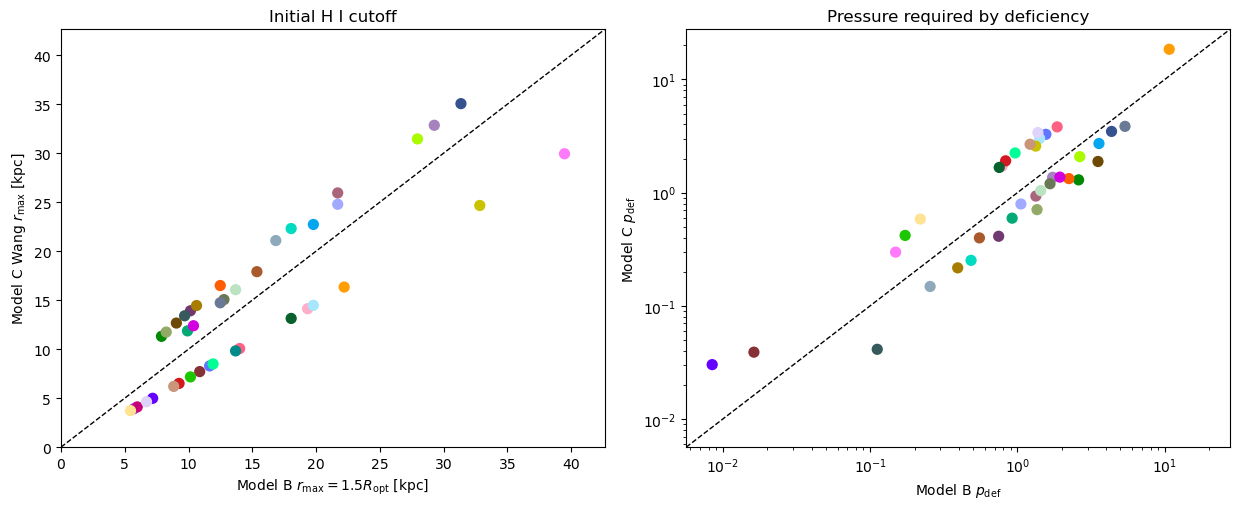

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
ax = axes[0]
ax.scatter(sample["rmax_B_kpc"], sample["rmax_C_kpc"], c=sample["galaxy_color"], s=50)
lims = [0, 1.08 * np.nanmax(sample[["rmax_B_kpc", "rmax_C_kpc"]].to_numpy())]
ax.plot(lims, lims, "k--", lw=1)
ax.set(xlim=lims, ylim=lims, xlabel=r"Model B $r_{\max}=1.5R_{\rm opt}$ [kpc]", ylabel=r"Model C Wang $r_{\max}$ [kpc]")
ax.set_title("Initial H I cutoff")

ax = axes[1]
valid = sample[["p_def_B", "p_def_C"]].notna().all(axis=1)
ax.scatter(sample.loc[valid, "p_def_B"], sample.loc[valid, "p_def_C"], c=sample.loc[valid, "galaxy_color"], s=50)
positive = sample.loc[valid, ["p_def_B", "p_def_C"]].to_numpy()
lo, hi = np.nanmin(positive) / 1.5, np.nanmax(positive) * 1.5
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set(xscale="log", yscale="log", xlim=(lo, hi), ylim=(lo, hi), xlabel=r"Model B $p_{\rm def}$", ylabel=r"Model C $p_{\rm def}$")
ax.set_title("Pressure required by deficiency")
fig.tight_layout()
plt.show()

## 11. Model-A external validation

The exact Gavazzi expected-mass inputs used galaxy-by-galaxy by Köppen are not available in the local MAUVE files, so Model A is represented by their published appendix values rather than reverse-engineered. This is an explicit completeness limit.

The most direct same-galaxy comparison below is therefore published Model-A $p_{\rm def}$ versus preferred Model-C $p_{\rm def}$, plus the already tested escape-only cluster-side $p_{\rm loc}$ regression. The revised `p_loc` additionally applies the LOS/escape maximum described above. Differences mix the intended AMIGA/Wang update with differences between the original and current input compilations; they should not be interpreted as the Wang effect alone. The B→C panel above isolates Wang cleanly.

In [10]:
model_a_compare = sample.loc[sample["p_def_K18"].notna() & sample["p_def_C"].notna(), [
    "Galaxy", "p_def_K18", "p_def_B", "p_def_C", "p_loc_K18", "p_loc_escape_only", "p_loc"
]].copy()
model_a_compare["C_over_A_pdef"] = model_a_compare["p_def_C"] / model_a_compare["p_def_K18"]
display(model_a_compare.sort_values("C_over_A_pdef"))
print(f"Finite published-Model-A / preferred-Model-C p_def comparisons: {len(model_a_compare)}")

,Galaxy,p_def_K18,p_def_B,p_def_C,p_loc_K18,p_loc_escape_only,p_loc,C_over_A_pdef
27,NGC4405,5.95,0.219,0.584,0.16,0.1781,0.1781,0.09815
28,NGC4419,15.3,1.859,3.81,0.3,0.338,0.338,0.249
35,NGC4580,10.92,1.376,3.389,0,0.05405,0.05405,0.3103
30,IC3392,6.08,0.8308,1.909,0.34,0.3766,0.3766,0.3141
21,NGC4694,0.06,0.00846,0.03021,0.01,0.1393,0.1393,0.5035
34,NGC4579,3.05,0.7516,1.668,0.7,0.7684,0.7684,0.547
17,NGC4424,0.06,0.01624,0.03892,0.05,0.2829,0.2829,0.6487
36,NGC4606,3.75,1.217,2.676,0.02,0.4142,0.4142,0.7135
24,NGC4293,24.8,10.72,18.48,0.02,0.06865,0.06865,0.745
14,NGC4330,0.86,1.358,0.7074,0.52,0.5721,0.5721,0.8225


Finite published-Model-A / preferred-Model-C p_def comparisons: 30


## 12. Monte Carlo uncertainty propagation

Each realization samples:

1. HyperLeda `logd25` and $T$;
2. morphology-dependent AMIGA intrinsic scatter;
3. observed $\log M_{\rm HI}$ (0.10 dex provisional uncertainty);
4. Wang size-mass scatter (0.06 dex);
5. rotation speed with its literature `e_vrot`, or 1% of the reported value when that error is unavailable;
6. M87 LOS velocity ($1256\pm36$ km s$^{-1}$), followed by $v_{\rm upper}=\max(v_{\rm esc},|v_{\rm LOS}-v_{\rm M87}|)$;
7. $p_{\rm loc}$ with a factor-of-two lognormal model uncertainty;
8. VIVA radius with 0.10 dex uncertainty where available.

The morphology bin is selected anew from each $T$ draw, so uncertainty across a bin boundary is propagated. Draws with ${\rm DEF}\le0$ have no valid deficiency-inverted stripping radius. For this reason the results distinguish:

- `P_DEF_positive`: fraction of all draws with a valid deficiency inversion;
- `P_def_gt2_given_positive`: threshold probability conditional on those valid draws;
- `P_def_gt2_joint`: fraction of all draws that are both deficient and above the threshold.

In [11]:
rng = np.random.default_rng(RNG_SEED)
draws = {}
mc_rows = []

def q16_50_84(values):
    finite = np.asarray(values)[np.isfinite(values)]
    return (np.nan, np.nan, np.nan) if finite.size == 0 else tuple(np.percentile(finite, [16, 50, 84]))

for row in sample.itertuples(index=False):
    logd = rng.normal(row.logd25, row.e_logd25, N_MC)
    t_draw = rng.normal(row.t, row.e_t, N_MC)
    d25 = angular_diameter_kpc(logd)
    ropt = 0.5 * d25
    aa, bb, ss = amiga_parameters(t_draw)
    logm0 = aa * (2.0 * np.log10(d25)) + bb + rng.normal(0.0, ss, N_MC)
    logmobs = rng.normal(row.logMHI, SIGMA_LOG_MHI_OBS_DEX, N_MC)
    deficiency = logm0 - logmobs
    vrot = np.clip(rng.normal(row.vrot, row.e_vrot_used, N_MC), 1.0, None)

    rmax_b = RHI_MAX_OVER_ROPT_B * ropt
    log_dhi = WANG_SLOPE * logm0 + WANG_INTERCEPT + rng.normal(0.0, WANG_SCATTER_DEX, N_MC)
    rmax_c = 0.5 * 10.0 ** log_dhi
    pdef_b = required_pressure(deficiency, ropt, logm0, rmax_b, vrot)
    pdef_c = required_pressure(deficiency, ropt, logm0, rmax_c, vrot)
    m87_vlos = rng.normal(M87_VLOS_KMS, M87_VLOS_ERR_KMS, N_MC)
    v_relative_los = np.abs(row.v_los_kms - m87_vlos)
    v_upper = np.maximum(row.v_esc_kms, v_relative_los)
    ploc_central = row.n_icm_cm3 * v_upper**2 / 1_000.0
    ploc = ploc_central * 10.0 ** rng.normal(0.0, SIGMA_LOG_PLOC_DEX, N_MC)
    ratio_b = pdef_b / ploc
    ratio_c = pdef_c / ploc

    if np.isfinite(row.r_HI_iso_kpc):
        r_obs = row.r_HI_iso_kpc * 10.0 ** rng.normal(0.0, SIGMA_LOG_RHI_OBS_DEX, N_MC)
        pcfg_c = pressure_at_radius(r_obs, ropt, logm0, rmax_c, vrot)
        ratio_cfg = pcfg_c / ploc
        cfg_to_def = pcfg_c / pdef_c
        p_r_obs_within = np.mean(r_obs <= rmax_c)
    else:
        r_obs = np.full(N_MC, np.nan)
        pcfg_c = np.full(N_MC, np.nan)
        ratio_cfg = np.full(N_MC, np.nan)
        cfg_to_def = np.full(N_MC, np.nan)
        p_r_obs_within = np.nan

    valid_def = np.isfinite(ratio_c)
    def_q = q16_50_84(ratio_c)
    cfg_q = q16_50_84(ratio_cfg)
    pcfg_q = q16_50_84(pcfg_c)
    cfgdef_q = q16_50_84(cfg_to_def)
    pdef_q = q16_50_84(pdef_c)
    ploc_q = q16_50_84(ploc)

    draws[row.Galaxy] = {
        "ratio_def_B": ratio_b, "ratio_def_C": ratio_c, "ratio_cfg_C": ratio_cfg,
        "cfg_to_def_C": cfg_to_def, "deficiency": deficiency,
        "rmax_C": rmax_c, "r_obs": r_obs,
    }
    mc_rows.append({
        "Galaxy": row.Galaxy,
        "P_DEF_positive": valid_def.mean(),
        "P_def_gt2_given_positive": np.mean(ratio_c[valid_def] > 2.0) if valid_def.any() else np.nan,
        "P_def_gt2_joint": np.mean(valid_def & (ratio_c > 2.0)),
        "ploc_p16": ploc_q[0], "ploc_p50": ploc_q[1], "ploc_p84": ploc_q[2],
        "pdef_C_p16": pdef_q[0], "pdef_C_p50": pdef_q[1], "pdef_C_p84": pdef_q[2],
        "ratio_def_C_p16": def_q[0], "ratio_def_C_p50": def_q[1], "ratio_def_C_p84": def_q[2],
        "pcfg_C_p16": pcfg_q[0], "pcfg_C_p50": pcfg_q[1], "pcfg_C_p84": pcfg_q[2],
        "ratio_cfg_C_p16": cfg_q[0], "ratio_cfg_C_p50": cfg_q[1], "ratio_cfg_C_p84": cfg_q[2],
        "cfg_to_def_C_p16": cfgdef_q[0], "cfg_to_def_C_p50": cfgdef_q[1], "cfg_to_def_C_p84": cfgdef_q[2],
        "P_r_HIobs_within_rmax_C": p_r_obs_within,
    })

mc = pd.DataFrame(mc_rows)
results = sample.merge(mc, on="Galaxy", validate="one_to_one")
print(f"Monte Carlo complete: {N_MC:,} draws × {len(results)} galaxies.")

Monte Carlo complete: 20,000 draws × 40 galaxies.


## 13. Full numerical result table

This table is the principal machine-readable notebook output. It keeps deterministic pressures, Monte Carlo intervals, threshold probabilities, VIVA coverage, and the physical cutoff-consistency diagnostic together.

In [12]:
result_columns = [
    "Galaxy", "stage_label", "DEF", "DHI0_Wang_kpc", "rmax_C_kpc", "r_HI_iso_kpc",
    "v_los_kms", "v_relative_los_kms", "v_esc_kms", "v_upper_kms", "v_upper_source",
    "p_loc_escape_only", "p_loc", "p_def_B", "p_def_C", "p_cfg_C",
    "ratio_def_C", "ratio_cfg_C", "ratio_cfg_to_def_C",
    "ploc_p16", "ploc_p50", "ploc_p84",
    "pdef_C_p16", "pdef_C_p50", "pdef_C_p84",
    "ratio_def_C_p16", "ratio_def_C_p50", "ratio_def_C_p84",
    "ratio_cfg_C_p16", "ratio_cfg_C_p50", "ratio_cfg_C_p84",
    "cfg_to_def_C_p16", "cfg_to_def_C_p50", "cfg_to_def_C_p84",
    "P_DEF_positive", "P_def_gt2_given_positive", "P_def_gt2_joint",
    "P_r_HIobs_within_rmax_C", "viva_beyond_inferred_initial_disk",
]
display(results[result_columns])

,Galaxy,stage_label,DEF,DHI0_Wang_kpc,rmax_C_kpc,r_HI_iso_kpc,v_los_kms,v_relative_los_kms,v_esc_kms,v_upper_kms,v_upper_source,p_loc_escape_only,p_loc,p_def_B,p_def_C,p_cfg_C,ratio_def_C,ratio_cfg_C,ratio_cfg_to_def_C,ploc_p16,ploc_p50,ploc_p84,pdef_C_p16,pdef_C_p50,pdef_C_p84,ratio_def_C_p16,ratio_def_C_p50,ratio_def_C_p84,ratio_cfg_C_p16,ratio_cfg_C_p50,ratio_cfg_C_p84,cfg_to_def_C_p16,cfg_to_def_C_p50,cfg_to_def_C_p84,P_DEF_positive,P_def_gt2_given_positive,P_def_gt2_joint,P_r_HIobs_within_rmax_C,viva_beyond_inferred_initial_disk
0,NGC4189,pre-peak,0.4041,22.61,11.3,NaN,1995,739,1499,1499,Köppen escape speed,0.1532,0.1532,2.599,1.297,NaN,8.463,NaN,NaN,0.0775,0.1529,0.3065,0.5054,1.26,2.954,2.609,8.13,24.5,NaN,NaN,NaN,NaN,NaN,NaN,0.9633,0.8886,0.8559,NaN,False
1,NGC4192,pre-peak,0.3648,59.87,29.93,22.6,-118,1374,1450,1450,Köppen escape speed,0.1206,0.1206,0.1488,0.298,0.1322,2.471,1.096,0.4437,0.06014,0.121,0.2386,0.2041,0.4868,1.19,1.346,4.06,12.42,0.4795,1.27,3.316,0.1421,0.3243,0.7212,0.9268,0.7383,0.6843,0.8145,False
2,NGC4222,pre-peak,0.5305,27.83,13.91,8.5,225,1031,1563,1563,Köppen escape speed,0.2092,0.2092,0.7452,0.4114,0.08158,1.967,0.39,0.1983,0.1048,0.2095,0.4177,0.18,0.4077,0.9308,0.6619,1.955,5.729,0.1407,0.3851,1.027,0.08173,0.1986,0.4663,0.9945,0.4917,0.489,0.921,False
3,NGC4254,pre-peak,0.09461,44.61,22.3,10.2,2453,1197,1572,1572,Köppen escape speed,0.2191,0.2191,0.4839,0.2521,0.9925,1.151,4.531,3.938,0.1094,0.2182,0.4392,0.185,0.4231,0.9905,0.6639,1.96,5.816,1.73,4.42,11.43,1.065,2.531,6.273,0.6391,0.4927,0.3149,0.9869,False
4,NGC4294,pre-peak,0.09037,26.8,13.4,10,421,835,1704,1704,Köppen escape speed,0.424,0.424,0.1116,0.04127,0.04196,0.09734,0.09896,1.017,0.2132,0.4285,0.8517,0.03133,0.07958,0.205,0.0588,0.1883,0.5898,0.03438,0.09868,0.2685,0.2079,0.5894,1.694,0.6638,0.02184,0.0145,0.806,False
5,NGC4321,pre-peak,0.3721,49.55,24.78,17.5,1579,323,1533,1533,Köppen escape speed,0.1805,0.1805,1.055,0.7934,0.2569,4.397,1.424,0.3238,0.09104,0.1812,0.3605,0.3892,0.8537,1.803,1.641,4.62,12.98,0.5283,1.423,3.764,0.1307,0.3115,0.7179,0.9737,0.7926,0.7718,0.8558,False
6,NGC4351,pre-peak,-0.2297,7.818,3.909,5.6,2388,1132,1830,1830,Köppen escape speed,0.8585,0.8585,NaN,NaN,0.01972,NaN,0.02296,NaN,0.4336,0.8576,1.727,0.0534,0.1344,0.3342,0.05013,0.1557,0.4957,0.01017,0.03174,0.09287,0.1079,0.279,0.7122,0.5422,0.01568,0.0085,0.4671,True
7,NGC4383,pre-peak,-1.177,8.206,4.103,19.1,1663,407,1499,1499,Köppen escape speed,0.1529,0.1529,NaN,NaN,0.0006554,NaN,0.004288,NaN,0.0771,0.1538,0.3044,0.03183,0.03952,0.0759,0.1447,0.2065,1.298,0.001276,0.00451,0.01568,0.123,0.1947,0.619,0.00025,0.2,5e-05,0.0005,True
8,NGC4396,pre-peak,0.4322,28.9,14.45,9,-115,1371,1580,1580,Köppen escape speed,0.2272,0.2272,0.3928,0.2164,0.0593,0.9526,0.261,0.274,0.114,0.2285,0.4488,0.09518,0.2286,0.5174,0.3288,0.9952,2.93,0.09388,0.261,0.7022,0.108,0.2654,0.6412,0.9805,0.2606,0.2555,0.9153,False
9,NGC4535,pre-peak,0.5574,65.68,32.84,20.2,1973,717,1499,1499,Köppen escape speed,0.153,0.153,1.732,1.366,0.3363,8.928,2.198,0.2462,0.07759,0.1518,0.3055,0.6945,1.436,3.004,3.472,9.387,25.89,0.8326,2.217,5.619,0.1052,0.2349,0.5097,0.998,0.9374,0.9356,0.9265,False


## 14. Forty per-galaxy PDFs of $p_{\rm def}/p_{\rm loc}$

All panels use common logarithmic bins. The black and red vertical lines mark ratios 1 and 2. A dashed blue curve overlays the configuration-based ratio where a VIVA radius exists. The annotation reports the probability that the deficiency inversion is defined and the conditional probability above 2.

Histograms are normalized over finite draws only; therefore a narrow histogram does **not** by itself imply a high probability of positive deficiency. Read it together with `P(DEF>0)`.

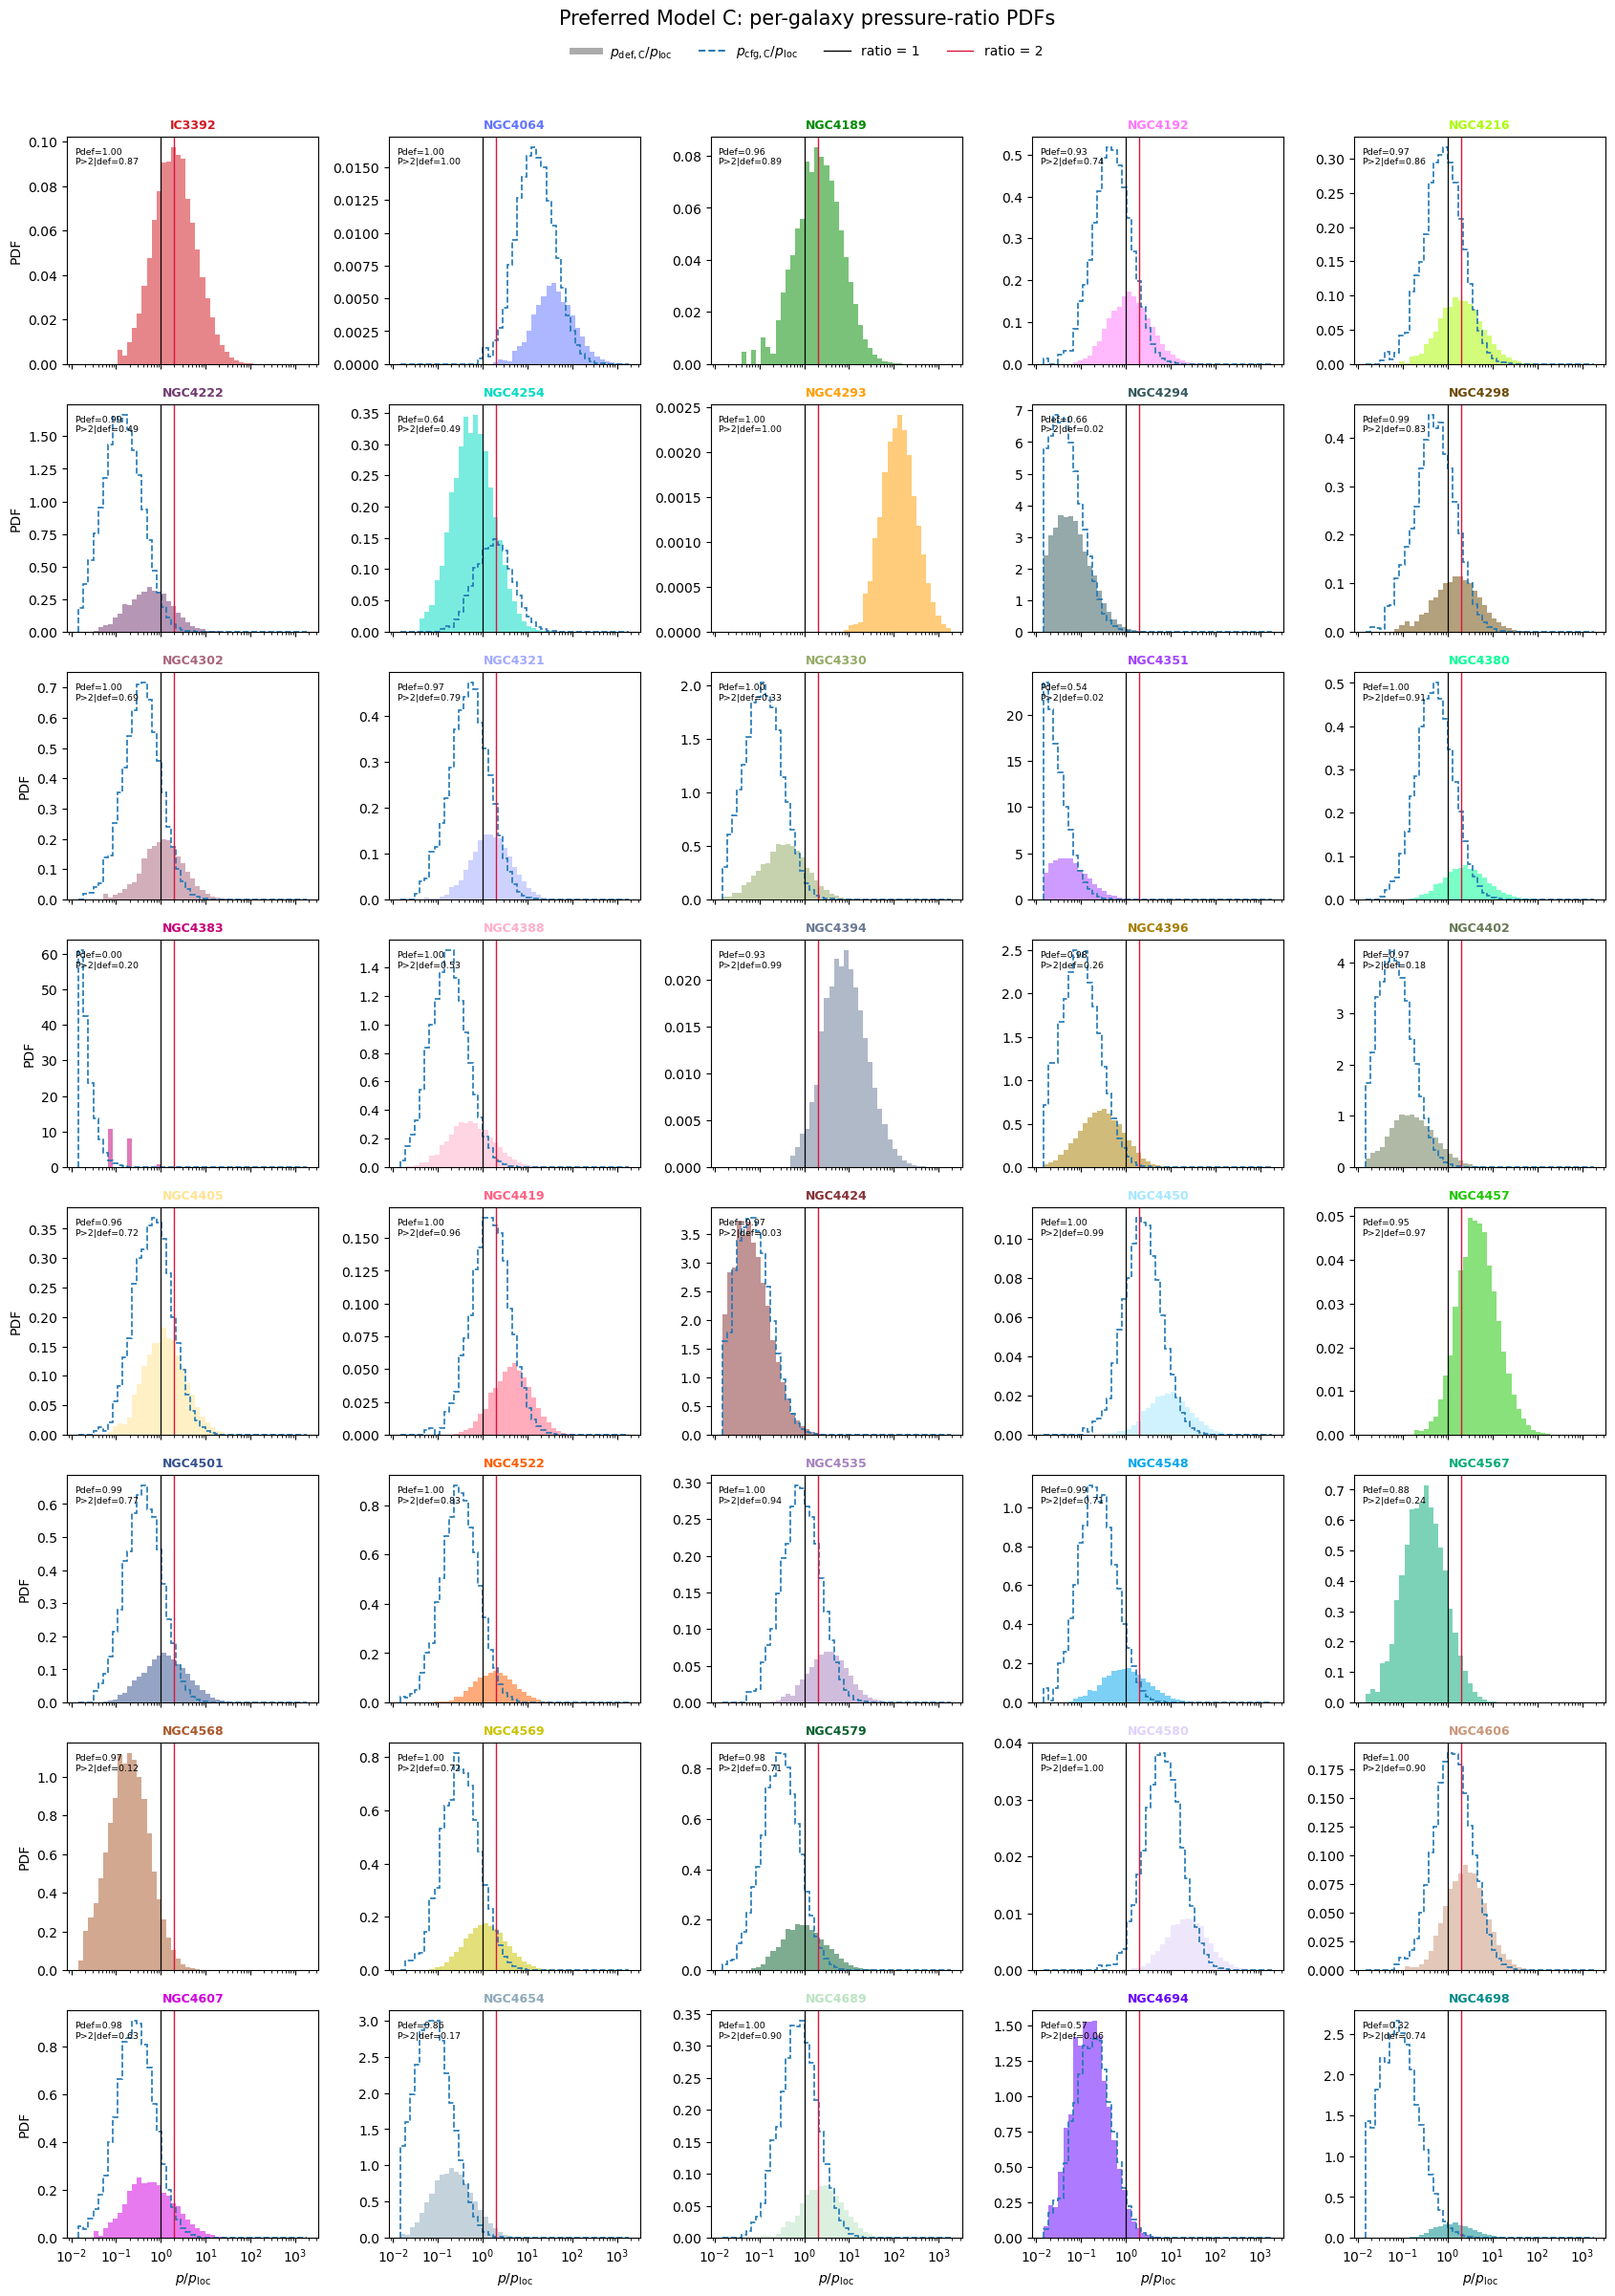

In [13]:
all_finite = np.concatenate([d["ratio_def_C"][np.isfinite(d["ratio_def_C"])] for d in draws.values()])
lo = max(1e-3, np.percentile(all_finite, 0.2) / 1.5)
hi = min(1e5, np.percentile(all_finite, 99.8) * 1.5)
bins = np.logspace(np.log10(lo), np.log10(hi), 48)

fig, axes = plt.subplots(8, 5, figsize=(17, 24), sharex=True, sharey=False)
for ax, row in zip(axes.flat, results.sort_values("Galaxy").itertuples(index=False)):
    rd = draws[row.Galaxy]["ratio_def_C"]
    rd = rd[np.isfinite(rd)]
    if rd.size:
        ax.hist(rd, bins=bins, density=True, histtype="stepfilled", alpha=0.52, color=row.galaxy_color)
    rc = draws[row.Galaxy]["ratio_cfg_C"]
    rc = rc[np.isfinite(rc)]
    if rc.size:
        ax.hist(rc, bins=bins, density=True, histtype="step", lw=1.2, color="tab:blue", linestyle="--")
    ax.axvline(1.0, color="black", lw=0.9)
    ax.axvline(2.0, color="crimson", lw=1.0)
    ax.set_xscale("log")
    ax.set_title(row.Galaxy, fontsize=9, color=row.galaxy_color, fontweight="bold")
    ax.text(0.03, 0.95, f"Pdef={row.P_DEF_positive:.2f}\nP>2|def={row.P_def_gt2_given_positive:.2f}",
            transform=ax.transAxes, va="top", fontsize=6.8)
for ax in axes[-1]:
    ax.set_xlabel(r"$p/p_{\rm loc}$")
for ax in axes[:, 0]:
    ax.set_ylabel("PDF")
legend = [
    Line2D([0], [0], color="0.35", lw=5, alpha=0.5, label=r"$p_{\rm def,C}/p_{\rm loc}$"),
    Line2D([0], [0], color="tab:blue", lw=1.4, ls="--", label=r"$p_{\rm cfg,C}/p_{\rm loc}$"),
    Line2D([0], [0], color="black", lw=1, label="ratio = 1"),
    Line2D([0], [0], color="crimson", lw=1, label="ratio = 2"),
]
fig.legend(handles=legend, loc="upper center", bbox_to_anchor=(0.5, 0.989), ncol=4, frameon=False)
fig.suptitle("Preferred Model C: per-galaxy pressure-ratio PDFs", y=0.999, fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.972))
plt.show()

## 15. Central Model-C pressure plane and central pressure ratio

The left panel is the deterministic central-value pressure plane. The right panel shows the same central $p_{\rm def,C}/p_{\rm loc}$ ratio galaxy by galaxy. Neither panel uses Monte Carlo percentiles. Galaxies with non-positive central AMIGA deficiency are omitted and named explicitly.
Every finite central-value galaxy above the factor-of-two boundary $p_{\rm def,C}/p_{\rm loc}>2$ is annotated by name in the new central panel.


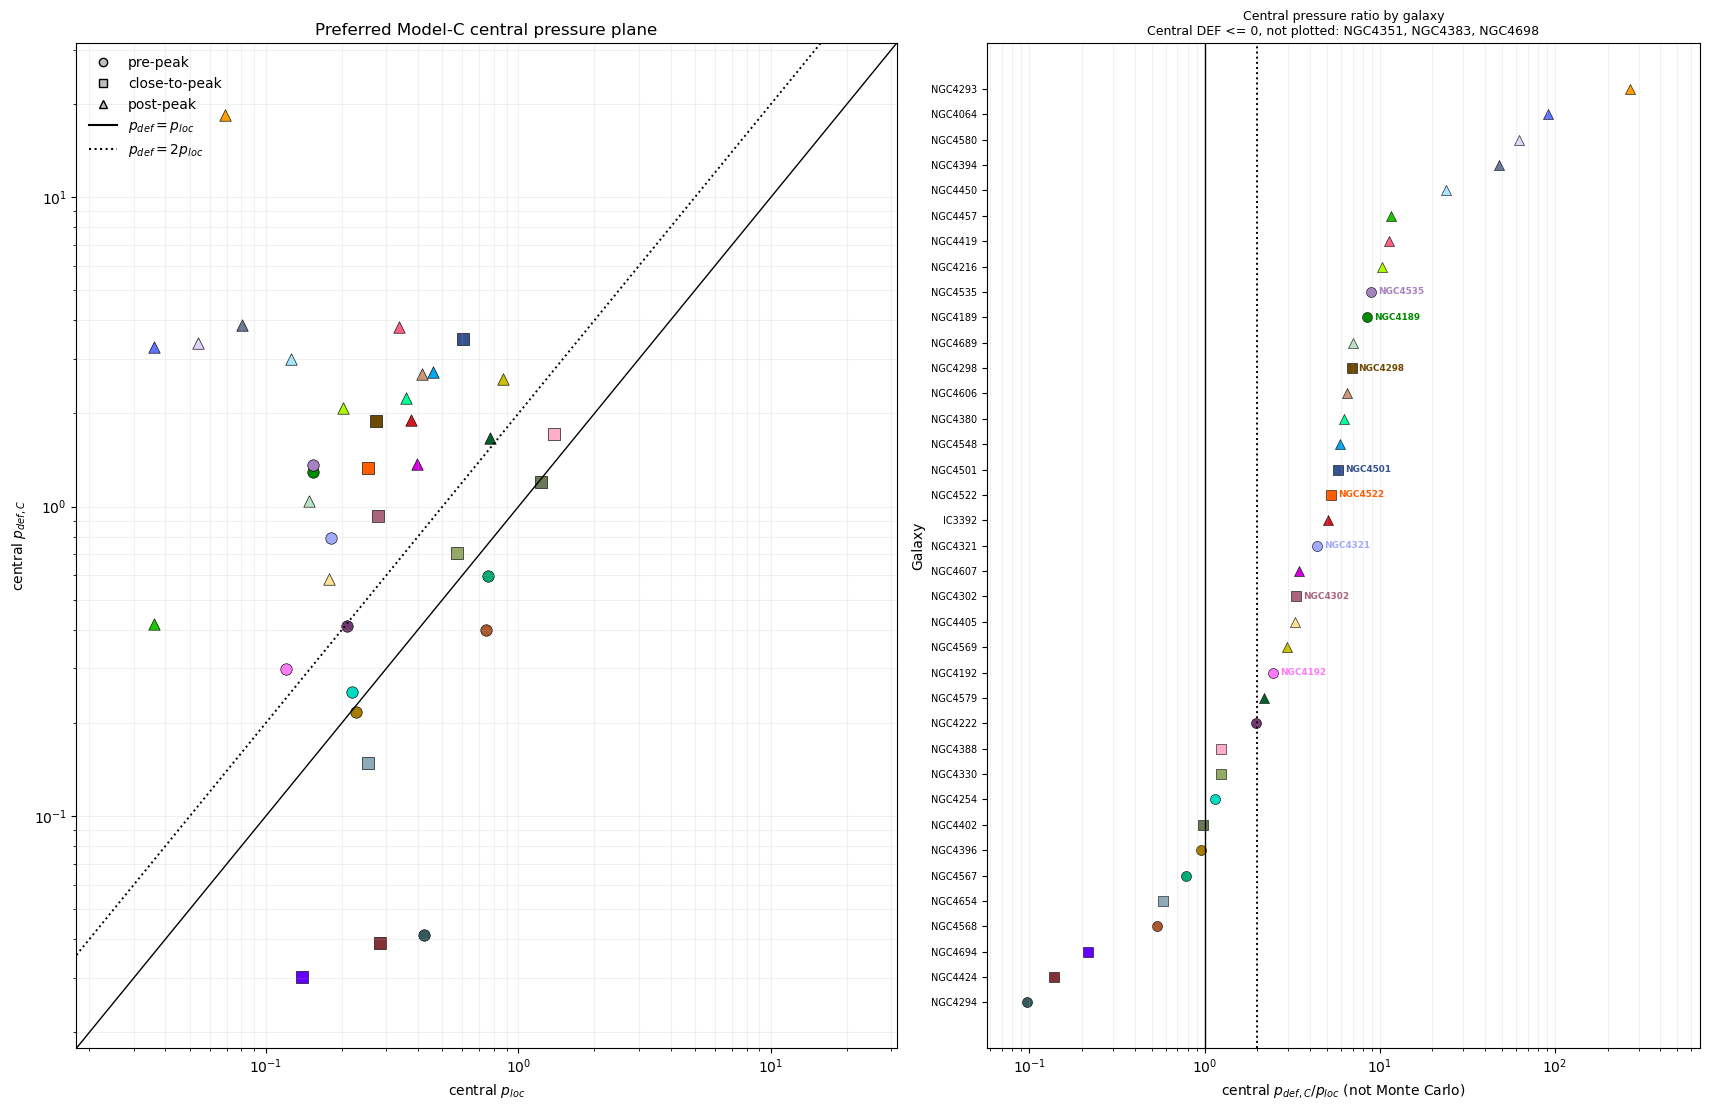

Central DEF <= 0 (not plotted in central panels): NGC4351, NGC4383, NGC4698
Central-ratio pre-/close-to-peak galaxies above 2: NGC4189, NGC4192, NGC4321, NGC4535, NGC4298, NGC4302, NGC4501, NGC4522


In [14]:
stage_markers = {1: "o", 2: "s", 3: "^"}
stage_labels = {1: "pre-peak", 2: "close-to-peak", 3: "post-peak"}
fig, (ax_plane, ax_ratio) = plt.subplots(
    1, 2, figsize=(17.2, 11.2), gridspec_kw={"width_ratios": [1.15, 1.0]}
)
finite = np.isfinite(results["p_def_C"]) & np.isfinite(results["p_loc"])
for _, row in results.loc[finite].iterrows():
    ax_plane.scatter(
        row["p_loc"], row["p_def_C"], s=68, marker=stage_markers[row["stage"]],
        color=row["galaxy_color"], edgecolor="black", linewidth=0.45,
    )
lo = min(results.loc[finite, ["p_loc", "p_def_C"]].min()) / 1.7
hi = max(results.loc[finite, ["p_loc", "p_def_C"]].max()) * 1.7
grid = np.geomspace(lo, hi, 300)
ax_plane.plot(grid, grid, color="black", linewidth=1.0, label=r"$p_{def}=p_{loc}$")
ax_plane.plot(grid, 2 * grid, color="black", linestyle=":", linewidth=1.4,
              label=r"$p_{def}=2p_{loc}$")
ax_plane.set(xscale="log", yscale="log", xlim=(lo, hi), ylim=(lo, hi),
             xlabel=r"central $p_{loc}$", ylabel=r"central $p_{def,C}$")
ax_plane.grid(which="both", alpha=0.18)
handles = [Line2D([], [], marker=stage_markers[s], linestyle="None", color="0.35",
                  markerfacecolor="0.75", markeredgecolor="black", label=stage_labels[s])
           for s in (1, 2, 3)]
handles += [Line2D([], [], color="black", label=r"$p_{def}=p_{loc}$"),
            Line2D([], [], color="black", linestyle=":", label=r"$p_{def}=2p_{loc}$")]
ax_plane.legend(handles=handles, frameon=False, loc="upper left")
ax_plane.set_title("Preferred Model-C central pressure plane")

central_valid = np.isfinite(results["ratio_def_C"]) & (results["ratio_def_C"] > 0)
central_ranked = results.loc[central_valid].sort_values("ratio_def_C").reset_index(drop=True)
ypos = np.arange(len(central_ranked))
for y, (_, row) in zip(ypos, central_ranked.iterrows()):
    ax_ratio.scatter(row["ratio_def_C"], y, s=52, color=row["galaxy_color"],
                     marker=stage_markers[row["stage"]], edgecolor="black", linewidth=0.4)
    if row["stage"] in (1, 2) and row["ratio_def_C"] > 2.0:
        ax_ratio.annotate(
            row["Galaxy"], (row["ratio_def_C"], y),
            xytext=(5, 0), textcoords="offset points", ha="left", va="center",
            fontsize=6.4, fontweight="bold", color=row["galaxy_color"],
        )
ax_ratio.set_xlim(
    central_ranked["ratio_def_C"].min() / 1.7,
    central_ranked["ratio_def_C"].max() * 2.5,
)
ax_ratio.axvline(1.0, color="black", linewidth=1.0)
ax_ratio.axvline(2.0, color="black", linestyle=":", linewidth=1.4)
ax_ratio.set_xscale("log")
ax_ratio.set_yticks(ypos, central_ranked["Galaxy"], fontsize=7)
ax_ratio.set_xlabel(r"central $p_{def,C}/p_{loc}$ (not Monte Carlo)")
ax_ratio.set_ylabel("Galaxy")
ax_ratio.grid(axis="x", which="both", alpha=0.18)
negative_central_names = results.loc[results["DEF"] <= 0, "Galaxy"].tolist()
ax_ratio.set_title(
    "Central pressure ratio by galaxy\n"
    + "Central DEF <= 0, not plotted: " + ", ".join(negative_central_names), fontsize=9,
)
fig.tight_layout()
plt.show()
print("Central DEF <= 0 (not plotted in central panels): " + ", ".join(negative_central_names))
central_nonpost_gt2_names = results.loc[
    central_valid & results["stage"].isin([1, 2]) & (results["ratio_def_C"] > 2.0),
    "Galaxy",
].tolist()
print("Central-ratio pre-/close-to-peak galaxies above 2: " + ", ".join(central_nonpost_gt2_names))


## 16. Main environmental-stage diagnostic: Monte Carlo and central values

The left panel retains the Monte Carlo deficiency- and configuration-pressure ratios. The added right panel uses only the deterministic central $p_{\rm def,C}/p_{\rm loc}$. Central non-positive-deficiency galaxies are not plotted and are named in the right-panel text box.
Every finite central-value galaxy above the factor-of-two boundary $p_{\rm def,C}/p_{\rm loc}>2$ is annotated by name in the new central panel.


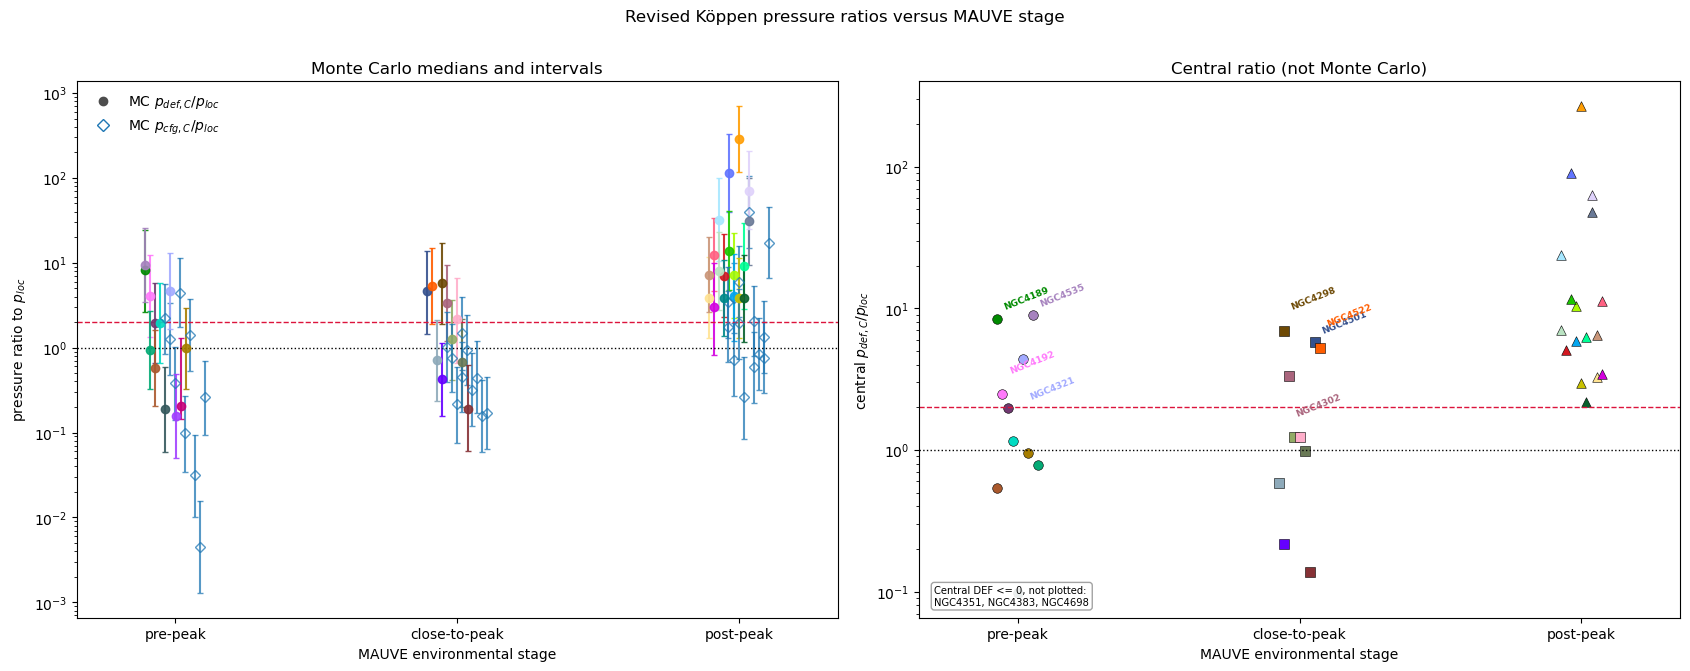

Central-ratio pre-/close-to-peak galaxies above 2: NGC4189, NGC4192, NGC4321, NGC4535, NGC4298, NGC4302, NGC4501, NGC4522


In [15]:
stage_x = {"pre-peak": 1, "close-to-peak": 2, "post-peak": 3}
fig, (ax_mc, ax_central) = plt.subplots(1, 2, figsize=(17.0, 6.6))
for i, row in enumerate(results.itertuples(index=False)):
    x0 = stage_x[row.stage_label] + ((i % 9) - 4) * 0.018
    if np.isfinite(row.ratio_def_C_p50):
        y = row.ratio_def_C_p50
        yerr = [[y - row.ratio_def_C_p16], [row.ratio_def_C_p84 - y]]
        ax_mc.errorbar(x0 - 0.035, y, yerr=yerr, fmt="o", color=row.galaxy_color,
                       ms=6, capsize=2, alpha=0.9)
    if np.isfinite(row.ratio_cfg_C_p50):
        y = row.ratio_cfg_C_p50
        yerr = [[y - row.ratio_cfg_C_p16], [row.ratio_cfg_C_p84 - y]]
        ax_mc.errorbar(x0 + 0.035, y, yerr=yerr, fmt="D", mfc="none", mec="tab:blue",
                       ecolor="tab:blue", ms=5, capsize=2, alpha=0.75)
ax_mc.axhline(1, color="black", ls=":", lw=1)
ax_mc.axhline(2, color="crimson", ls="--", lw=1)
ax_mc.set_yscale("log")
ax_mc.set_xticks([1, 2, 3], ["pre-peak", "close-to-peak", "post-peak"])
ax_mc.set(xlim=(0.65, 3.35), ylabel=r"pressure ratio to $p_{loc}$",
          xlabel="MAUVE environmental stage")
ax_mc.legend(handles=[
    Line2D([0], [0], marker="o", color="0.3", lw=0, label=r"MC $p_{def,C}/p_{loc}$"),
    Line2D([0], [0], marker="D", mfc="none", mec="tab:blue", color="tab:blue", lw=0,
           label=r"MC $p_{cfg,C}/p_{loc}$"),
], frameon=False)
ax_mc.set_title("Monte Carlo medians and intervals")

central_valid = np.isfinite(results["ratio_def_C"]) & (results["ratio_def_C"] > 0)
central_label_number = 0
for i, row in enumerate(results.loc[central_valid].itertuples(index=False)):
    x0 = stage_x[row.stage_label] + ((i % 9) - 4) * 0.018
    ax_central.scatter(x0, row.ratio_def_C, s=48, color=row.galaxy_color,
                       marker={1: "o", 2: "s", 3: "^"}[row.stage],
                       edgecolor="black", linewidth=0.4)
    if row.stage in (1, 2) and row.ratio_def_C > 2.0:
        label_offsets = [(4, 5), (4, 14), (4, -12)]
        offset = label_offsets[central_label_number % len(label_offsets)]
        ax_central.annotate(
            row.Galaxy, (x0, row.ratio_def_C), xytext=offset,
            textcoords="offset points", fontsize=6.6, fontweight="bold",
            color=row.galaxy_color, rotation=22, ha="left",
            va="bottom" if offset[1] >= 0 else "top", zorder=3,
        )
        central_label_number += 1
ax_central.axhline(1, color="black", ls=":", lw=1)
ax_central.axhline(2, color="crimson", ls="--", lw=1)
ax_central.set_yscale("log")
ax_central.set_xticks([1, 2, 3], ["pre-peak", "close-to-peak", "post-peak"])
ax_central.set(xlim=(0.65, 3.35), ylabel=r"central $p_{def,C}/p_{loc}$",
               xlabel="MAUVE environmental stage")
negative_central_names = results.loc[results["DEF"] <= 0, "Galaxy"].tolist()
ax_central.set_title("Central ratio (not Monte Carlo)")
ax_central.text(
    0.02, 0.02, "Central DEF <= 0, not plotted:\n" + ", ".join(negative_central_names),
    transform=ax_central.transAxes, ha="left", va="bottom", fontsize=7.2,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "0.6", "alpha": 0.9},
)
fig.suptitle("Revised Köppen pressure ratios versus MAUVE stage", y=1.01)
fig.tight_layout()
plt.show()
central_nonpost_gt2_names = results.loc[
    central_valid & results["stage"].isin([1, 2]) & (results["ratio_def_C"] > 2.0),
    "Galaxy",
].tolist()
print("Central-ratio pre-/close-to-peak galaxies above 2: " + ", ".join(central_nonpost_gt2_names))


## 17. Do deficiency and H I configuration encode the same pressure?

For VIVA-covered galaxies, this plot compares the two preferred-model estimates. The diagonal indicates $p_{\rm cfg}=p_{\rm def}$. Galaxies with central ${\rm DEF}\le0$ lack a deterministic $p_{\rm def}$, but may still contribute Monte Carlo summaries if some realizations are deficient.

This is not a fully independent comparison: both pressures share $D_{25}$, $M_{\rm HI,0}$, $v_{\rm rot}$, and the same analytic restoring-force law. Their independent information is the radius—integrated deficiency inversion versus resolved H I morphology.


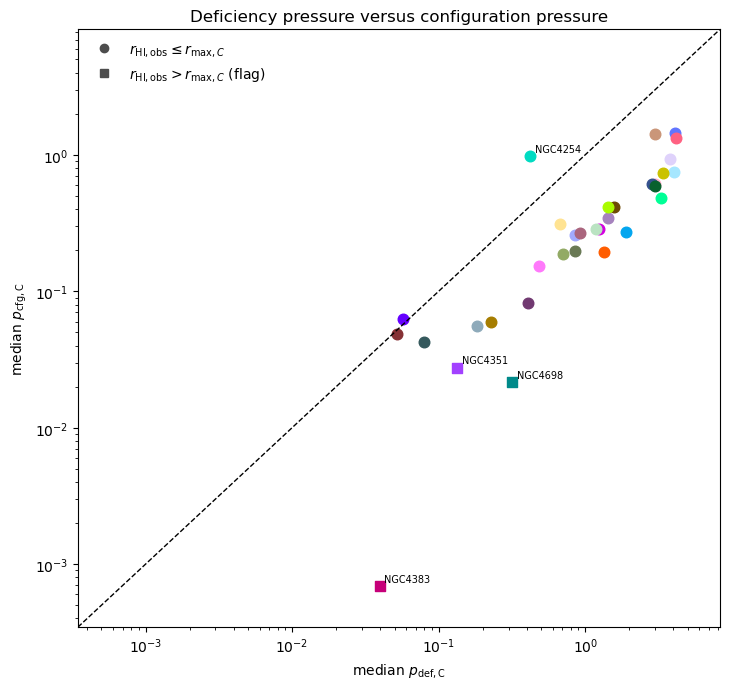

In [16]:
fig, ax = plt.subplots(figsize=(7.4, 7.0))
valid = results[["pdef_C_p50", "pcfg_C_p50"]].notna().all(axis=1)
for row in results.loc[valid].itertuples(index=False):
    ax.scatter(row.pdef_C_p50, row.pcfg_C_p50, s=58, color=row.galaxy_color,
               marker="s" if row.viva_beyond_inferred_initial_disk else "o")
    if row.viva_beyond_inferred_initial_disk or row.Galaxy == "NGC4254":
        ax.annotate(row.Galaxy, (row.pdef_C_p50, row.pcfg_C_p50), xytext=(3, 3), textcoords="offset points", fontsize=7)
vals = results.loc[valid, ["pdef_C_p50", "pcfg_C_p50"]].to_numpy()
lo, hi = np.nanmin(vals) / 2, np.nanmax(vals) * 2
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set(xscale="log", yscale="log", xlim=(lo, hi), ylim=(lo, hi),
       xlabel=r"median $p_{\rm def,C}$", ylabel=r"median $p_{\rm cfg,C}$")
ax.set_title("Deficiency pressure versus configuration pressure")
ax.legend(handles=[
    Line2D([0], [0], marker="o", color="0.3", lw=0, label=r"$r_{\rm HI,obs}\leq r_{\max,C}$"),
    Line2D([0], [0], marker="s", color="0.3", lw=0, label=r"$r_{\rm HI,obs}>r_{\max,C}$ (flag)"),
], frameon=False)
fig.tight_layout()
plt.show()

## 18. Automated guardrails and concise ranked output

These checks verify sample completeness, positive physical inputs, VIVA coverage, finite local pressures, MC bounds, and the explicit relationship between central deficiency and deterministic $p_{\rm def}$. They are structural/numerical checks—not a claim that the astrophysical model is uniquely correct.


In [17]:
expected_e_vrot_used = np.where(
    np.isfinite(results["e_vrot"]) & (results["e_vrot"] > 0),
    results["e_vrot"],
    VROT_FRACTIONAL_FALLBACK * results["vrot"],
)
assert np.allclose(results["e_vrot_used"], expected_e_vrot_used, equal_nan=True)

assert len(results) == 40 and results["Galaxy"].nunique() == 40
assert results[["D25_kpc", "Ropt_kpc", "rmax_B_kpc", "rmax_C_kpc", "v_esc_kms", "v_upper_kms", "p_loc"]].gt(0).all().all()
assert np.allclose(results["v_upper_kms"], np.maximum(results["v_esc_kms"], results["v_relative_los_kms"]))
assert (results["p_loc"] >= results["p_loc_escape_only"] - 1e-12).all()
assert results["has_viva_radius"].sum() == 33
assert results.loc[results["DEF"] <= 0, "p_def_C"].isna().all()
assert results.loc[results["DEF"] > 0, "p_def_C"].notna().all()
prob_cols = ["P_DEF_positive", "P_def_gt2_given_positive", "P_def_gt2_joint", "P_r_HIobs_within_rmax_C"]
for col in prob_cols:
    finite = results[col].dropna()
    assert finite.between(0, 1).all(), col

ranked = results[[
    "Galaxy", "stage_label", "P_DEF_positive", "P_def_gt2_given_positive",
    "ratio_def_C_p50", "ratio_cfg_C_p50", "cfg_to_def_C_p50",
    "P_r_HIobs_within_rmax_C"
]].sort_values(["P_def_gt2_given_positive", "P_DEF_positive"], ascending=False)
display(ranked)
print("All automated notebook guardrails passed.")

,Galaxy,stage_label,P_DEF_positive,P_def_gt2_given_positive,ratio_def_C_p50,ratio_cfg_C_p50,cfg_to_def_C_p50,P_r_HIobs_within_rmax_C
22,NGC4064,post-peak,1,1,114.5,39.79,0.3463,0.9994
24,NGC4293,post-peak,1,1,286.6,NaN,NaN,NaN
35,NGC4580,post-peak,0.9996,0.9997,70.03,17.14,0.2426,0.9788
29,NGC4450,post-peak,0.999,0.9944,31.93,5.976,0.1851,0.9725
26,NGC4394,post-peak,0.9289,0.9923,30.9,NaN,NaN,NaN
31,NGC4457,post-peak,0.9484,0.9671,13.58,NaN,NaN,NaN
28,NGC4419,post-peak,1,0.9647,12.36,3.856,0.3147,0.9994
9,NGC4535,pre-peak,0.998,0.9374,9.387,2.217,0.2349,0.9265
25,NGC4380,post-peak,0.9978,0.9056,9.174,1.334,0.1448,0.9222
38,NGC4689,post-peak,0.997,0.9027,8.034,1.932,0.2405,0.9906


All automated notebook guardrails passed.


## 19. Reading the result responsibly and next steps

1. **Start with `P_DEF_positive`.** A galaxy with a low value does not have a robust deficiency-based stripping pressure even if the finite-draw PDF looks narrow.
2. **Use the continuous ratios.** Ratio 2 is an empirical interpretive boundary, not a discontinuity in the physics.
3. **Treat square-symbol configuration points as model tension.** Their VIVA radius exceeds the median inferred initial Wang cutoff. This may reflect input/calibration scatter, disturbed/extraplanar gas, distance/system differences, or a mismatch between the assumed initial profile and reality.
4. **Do not overstate p_cfg coverage.** It is published-radius based for 33/40, not a new homogeneous remeasurement from H I maps.
5. **Model A remains an external reference.** A strict A→B→C decomposition for all 40 requires the original homogeneous Gavazzi/GoldMine expected-mass inputs and diameter system.
6. **Highest-value extension.** Acquire the resolved VIVA moment-0 maps, define a common deprojection and azimuthal-profile procedure, bootstrap the $1\,M_\odot\,{\rm pc}^{-2}$ crossing, and replace the provisional 0.10 dex radius error with measured per-galaxy posteriors.

Within these limits, Model B versus Model C cleanly isolates the main requested conceptual upgrade: the initial H I disk cutoff is inferred galaxy-by-galaxy from the AMIGA mass through the Wang size–mass relation, while the Köppen restoring-force and Virgo-side physics are held fixed.

7. **LOS/escape velocity rule.** Inspect `v_upper_source`. LOS-dominated rows indicate that the observed radial component alone exceeds the bound-model escape speed at the projected radius; this is a model-tension flag, not proof that the quantity is a strict 3D upper limit.
